In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [ ]:
import pandas as pd

df = pd.read_csv("merged_PrDeQuPeCOVID.csv", encoding='ISO-8859-1')

print(df["ownership_type"].unique())

# One-hot encode the 'Color' column
df_encoded = pd.get_dummies(df, columns=["ownership_type", "provider_type"])

# Binarize the Score column
df_encoded['Score_High'] = df_encoded['overall_rating'] > 3

# print(df_encoded)

df_encoded.to_csv('FinalClean_COVID.csv', index=False)

['For profit' 'Government' 'Non profit']


In [ ]:
import pandas as pd

df = pd.read_csv("merged_PrDeQuPe_data.csv", encoding='ISO-8859-1')

print(df["OWNERSHIP"].unique())

# One-hot encode the 'Color' column
df_encoded = pd.get_dummies(df, columns=["OWNERSHIP", "CERTIFICATION"])

# Binarize the Score column
df_encoded['Score_High'] = df_encoded['overall_rating'] > 3

# print(df_encoded)

df_encoded.to_csv('FinalClean_1519.csv', index=False)


['For profit' 'Non profit' 'Government']


In [ ]:
# Load the CSV
df = pd.read_csv("FinalClean_1519.csv", encoding='ISO-8859-1')

# Impute missing values in 'DeficiencyCount' using the mean
imputer = SimpleImputer(strategy="mean")
df["DeficiencyCount"] = imputer.fit_transform(df[["DeficiencyCount"]])

# Save the updated DataFrame
df.to_csv("FinalClean_151.csv", index=False)

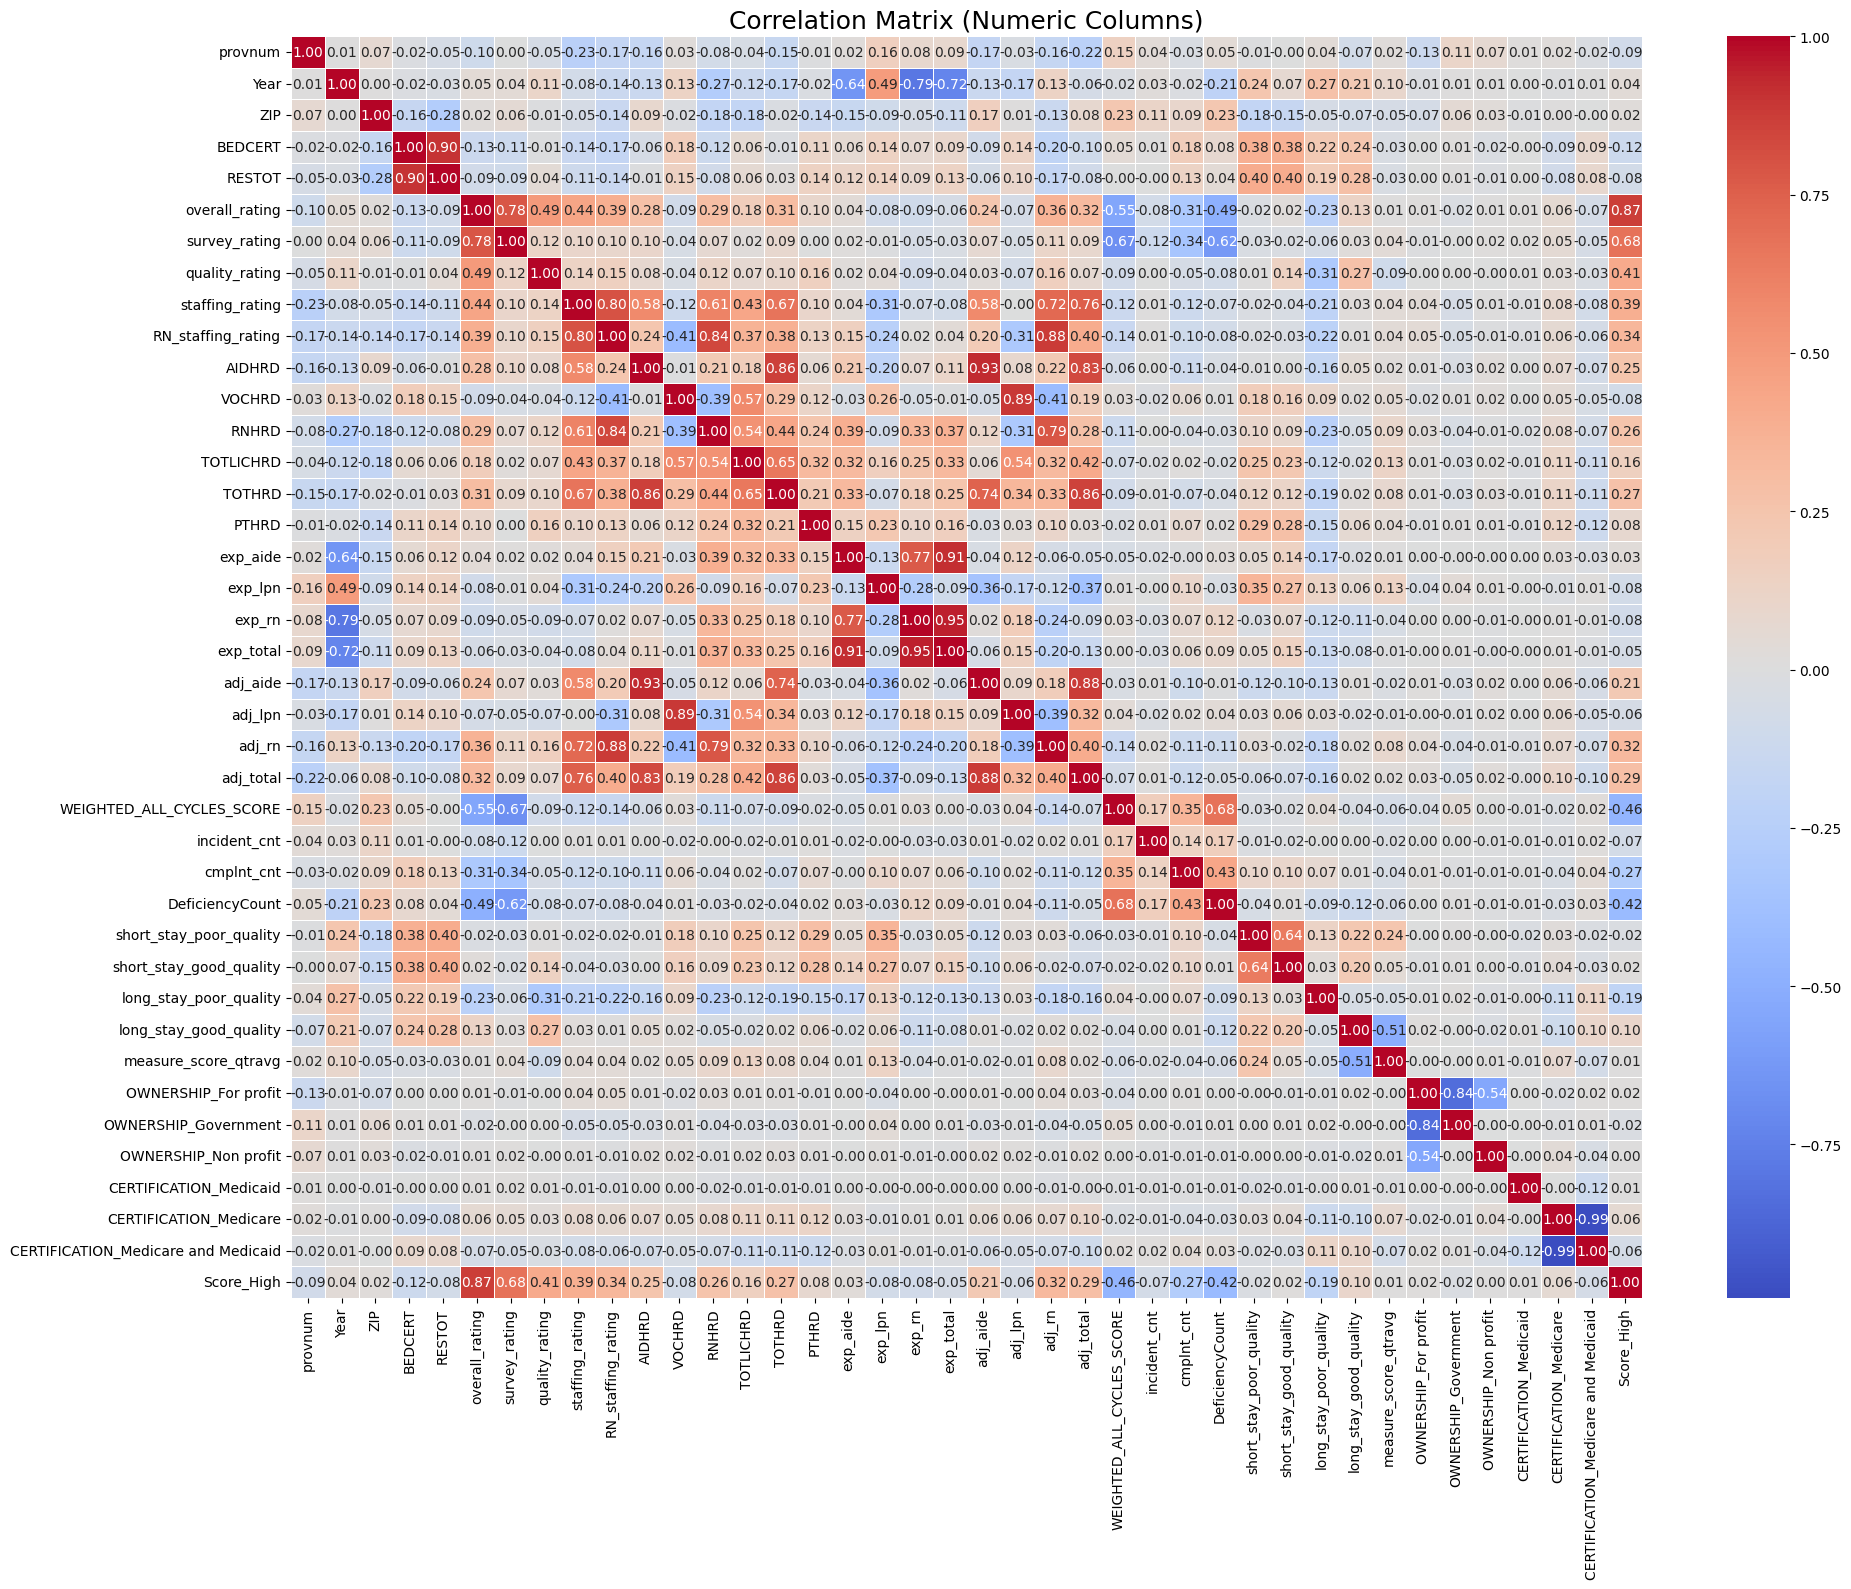

In [11]:
# Load the CSV file
df = pd.read_csv("FinalClean_151.csv")  # Make sure the path is correct

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the heatmap with annotations
plt.figure(figsize=(20, 16))
sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,       # Add correlation coefficients
    fmt=".2f",         # Format the numbers to 2 decimal places
    linewidths=0.5     # Optional: add lines between boxes
)
plt.title("Correlation Matrix (Numeric Columns)", fontsize=18)
plt.tight_layout()
plt.show()